<a href="https://colab.research.google.com/github/prnakyazze94/Data-608/blob/main/Nutrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

As poverty increases, does food insecurity also increase?

In [ ]:
Source: Food Prices and Nutrition, World Bank Databank. Click on a metadata icon for original source information to be used for citation.
https://databank.worldbank.org/source/food-prices-for-nutrition#

source for education: https://americadashboard.com/rankings/education

https://www.ers.usda.gov/topics/food-nutrition-assistance/food-security-in-the-us/key-statistics-graphics

https://www.fns.usda.gov/research/nutrition-education-coordination-report-congress-fy-2022

https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_income

In [ ]:
import pandas as pd

# GitHub raw file link
url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/World_Bank_food_prices"

# Read as tab-separated file
food_prices_df = pd.read_csv(url, sep="\t")

# Replace ".." with missing values (NaN)
food_prices_df = food_prices_df.replace("..", pd.NA)

# Preview
print(food_prices_df.head())

# Save locally as CSV
food_prices_df.to_csv("World_Bank_food_prices.csv", index=False)

print("Saved successfully as World_Bank_food_prices.csv")

             Classification Name Classification Code         Country Name  \
0  Food Prices for Nutrition 4.0             FPN 4.0              Albania   
1  Food Prices for Nutrition 4.0             FPN 4.0               Angola   
2  Food Prices for Nutrition 4.0             FPN 4.0  Antigua and Barbuda   
3  Food Prices for Nutrition 4.0             FPN 4.0              Armenia   
4  Food Prices for Nutrition 4.0             FPN 4.0            Australia   

  Country Code    Time Time Code  \
0          ALB  2024.0    YR2024   
1          AGO  2024.0    YR2024   
2          ATG  2024.0    YR2024   
3          ARM  2024.0    YR2024   
4          AUS  2024.0    YR2024   

  Millions of people who cannot afford a healthy diet [CoHD_unafford_n]  \
0                                                0.3                      
1                                               27.1                      
2                                               <NA>                      
3                   

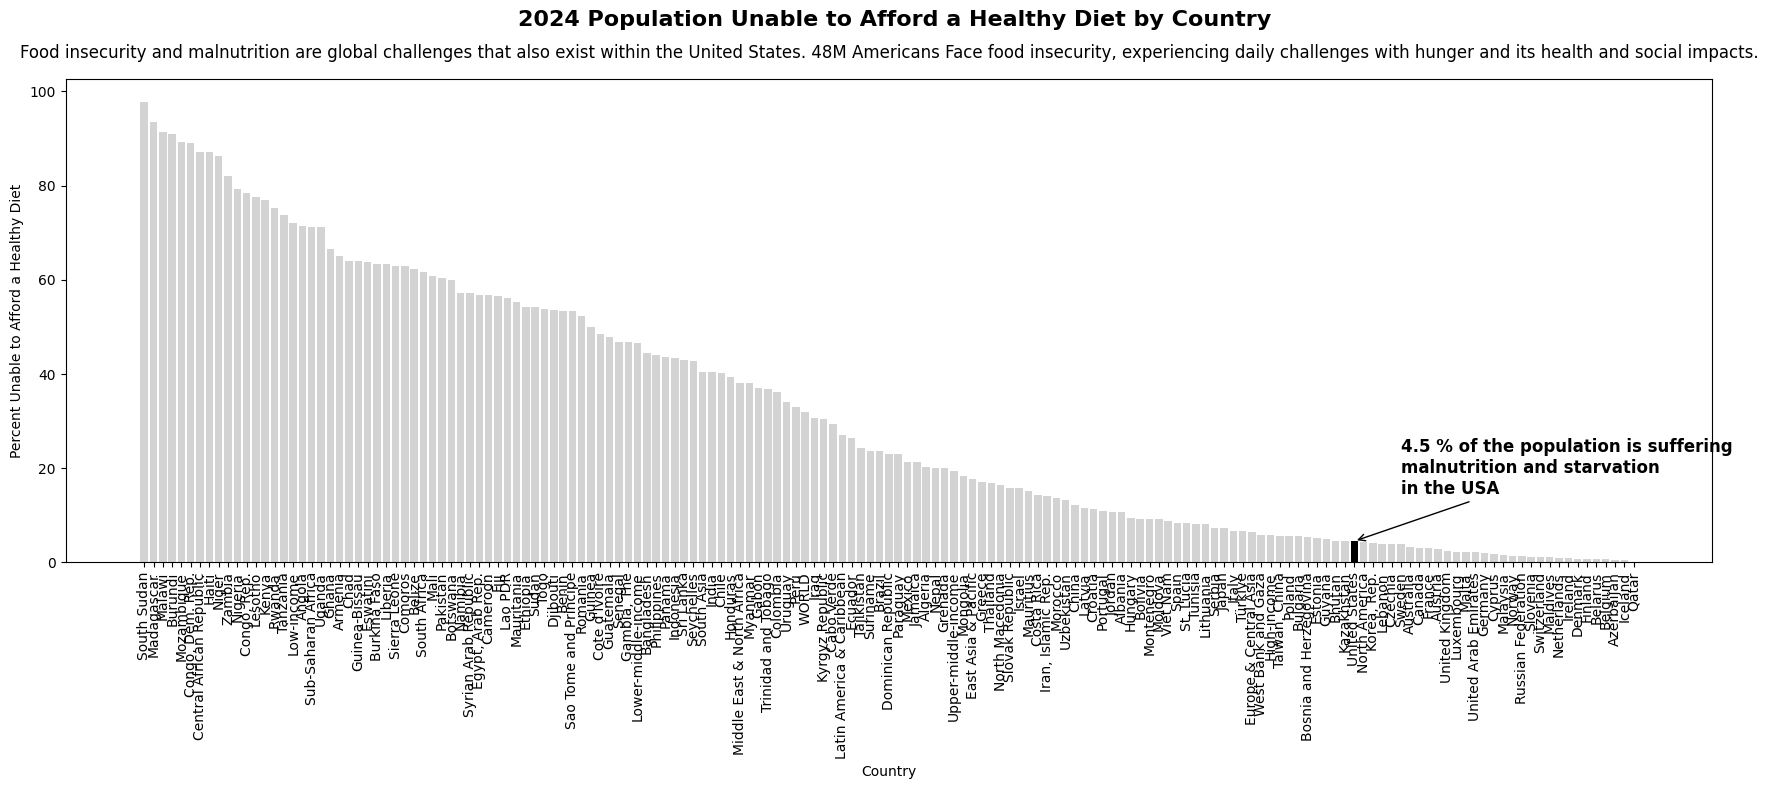

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# GitHub raw file link
url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/World_Bank_food_prices"

# Read tab-separated file
food_prices_df = pd.read_csv(url, sep="\t")

# Replace missing values
food_prices_df = food_prices_df.replace("..", pd.NA)

# Convert percentage column to numeric
percent_col = "Percent of the population who cannot afford a healthy diet [CoHD_headcount]"
food_prices_df[percent_col] = pd.to_numeric(food_prices_df[percent_col], errors="coerce")

# Select distinct countries
plot_df = (
    food_prices_df[["Country Name", percent_col]]
    .dropna()
    .drop_duplicates(subset=["Country Name"])
    .sort_values(percent_col, ascending=False)
)

# Create colors: USA black, others light gray
colors = [
    "black" if country == "United States" else "lightgrey"
    for country in plot_df["Country Name"]
]

# Plot
plt.figure(figsize=(18, 8))
plt.bar(plot_df["Country Name"], plot_df[percent_col], color=colors)

# Main title
plt.suptitle(
    "2024 Population Unable to Afford a Healthy Diet by Country",
    fontsize=16,
    y=0.98,
    fontweight='bold'

)

# Subtitle
plt.title(
    "Food insecurity and malnutrition are global challenges that also exist within the United States. 48M Americans Face food insecurity, experiencing daily challenges with hunger and its health and social impacts.",
    fontsize=12,
    pad=15
)

# Axis labels
plt.ylabel("Percent Unable to Afford a Healthy Diet")
plt.xlabel("Country")
plt.xticks(rotation=90)

# Add annotation for USA
usa_row = plot_df[plot_df["Country Name"] == "United States"]
if not usa_row.empty:
    usa_x = plot_df.index.get_loc(usa_row.index[0])
    usa_y = usa_row[percent_col].values[0]

    plt.annotate(
        "4.5 % of the population is suffering\nmalnutrition and starvation\nin the USA",
        xy=(usa_x, usa_y),
        xytext=(usa_x + 5, usa_y + 10), # Adjusted height for visibility
        arrowprops=dict(arrowstyle="->"),
        fontsize=12,
        fontweight='bold' # Optional: makes the key point stand out
    )

plt.tight_layout()
plt.show()

In [ ]:


Usdaurl = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/USDA_food_insecurity_state"
Usda_df = pd.read_csv(Usdaurl, sep="\t")
print(Usda_df.head())

  State Number of households (average 2022–2024)1 Number Interviewed  \
0    AK                                   283,000              1,143   
1    AL                                 2,075,000              1,886   
2   AR                                  1,270,000              1,805   
3    AZ                                 2,948,000              1,370   
4    CA                                13,990,000              8,112   

   Food insecurity prevalence (percent)      \
0                                      13.0   
1                                      12.1   
2                                      19.4   
3                                      13.1   
4                                      12.5   

  Statistical significance indicator for food insecurity prevalence  \
0                                                 No                  
1                                                 No                  
2                                                Yes                  


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

Usdaurl = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/USDA_food_insecurity_state"

# Read file
Usda_df = pd.read_csv(Usdaurl, sep="\t")

# Clean column names
Usda_df.columns = Usda_df.columns.str.strip()

In [64]:
Usda_df["Food insecurity prevalence (percent)"] = pd.to_numeric(
    Usda_df["Food insecurity prevalence (percent)"],
    errors="coerce"
)

In [65]:
Usda_df = Usda_df.dropna(subset=["State", "Food insecurity prevalence (percent)"])

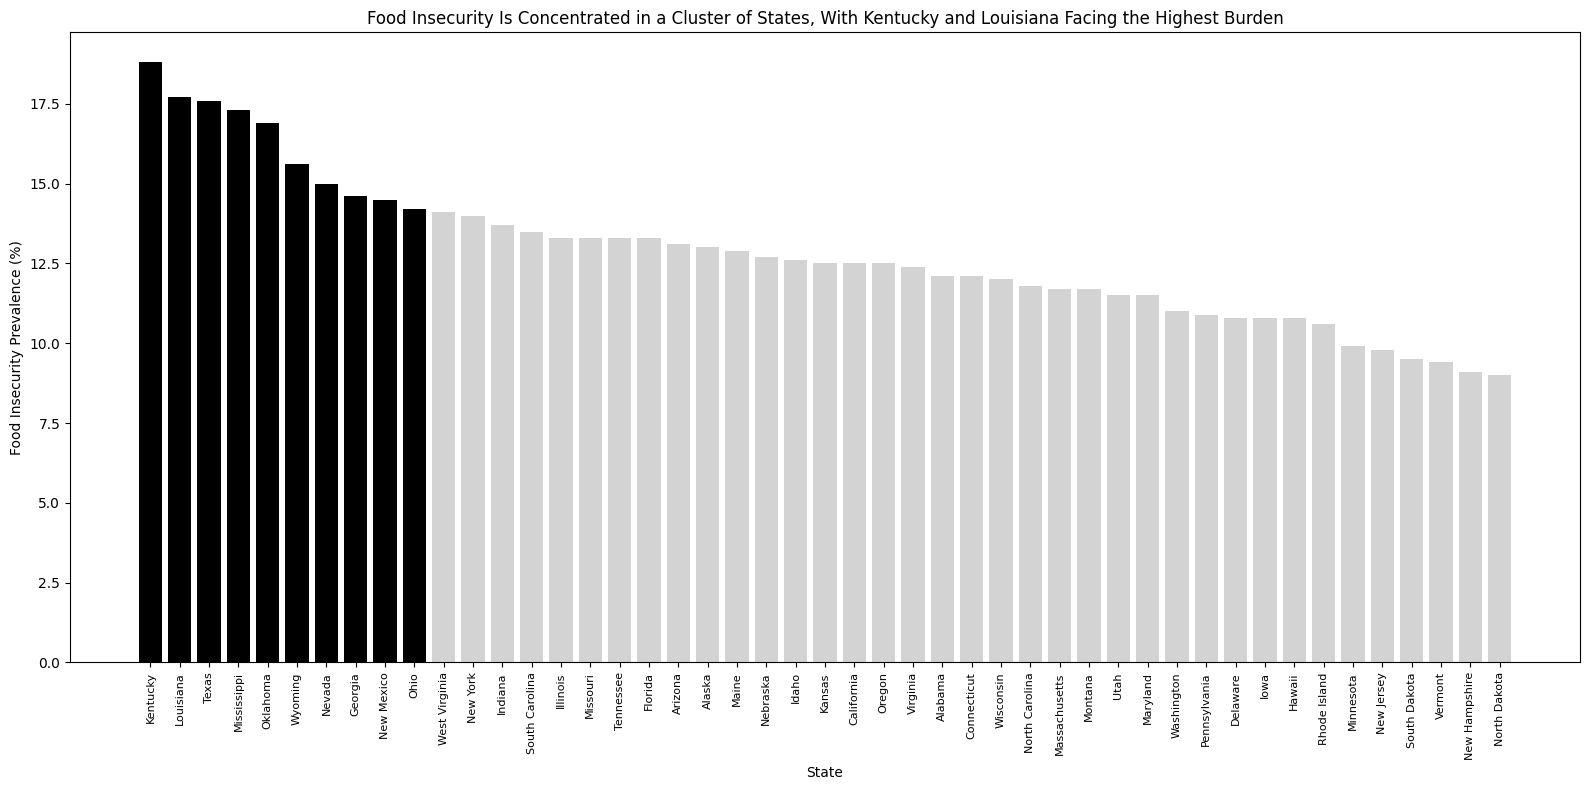

In [66]:
import pandas as pd
import matplotlib.pyplot as plt


# --- State abbreviation → full name mapping ---
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut',
    'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan',
    'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota',
    'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Convert abbreviations to full state names
Usda_df["State_Full"] = Usda_df["State"].map(state_map)

# Drop any missing mappings (just in case)
Usda_df = Usda_df.dropna(subset=["State_Full"])

# Sort by prevalence (high to low)
plot_df = Usda_df.sort_values(
    by="Food insecurity prevalence (percent)",
    ascending=False
)

# Select top 10 highest states
highest_10_states = plot_df.head(10)["State_Full"].astype(str)

# Color mapping
colors = [
    "black" if state in highest_10_states.values else "lightgrey"
    for state in plot_df["State_Full"].astype(str)
]

# Plot
plt.figure(figsize=(16, 8))
plt.bar(
    plot_df["State_Full"].astype(str),
    plot_df["Food insecurity prevalence (percent)"],
    color=colors
)

plt.title("Food Insecurity Is Concentrated in a Cluster of States, With Kentucky and Louisiana Facing the Highest Burden")
plt.xlabel("State")
plt.ylabel("Food Insecurity Prevalence (%)")

plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [67]:
 #GitHub raw CSV link
pov_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/census_gov_poverty.csv"

# Read CSV
poverty_df = pd.read_csv(pov_url)

# Preview first rows
print(poverty_df.head())

# Check column names
print(poverty_df.columns)

            Area  Poverty_Percent_2023
0  United States                  12.5
1        Alabama                  15.6
2         Alaska                  10.4
3        Arizona                  12.4
4       Arkansas                  15.7
Index(['Area', 'Poverty_Percent_2023'], dtype='object')


In [69]:
import pandas as pd

# URL of the raw dataset
income_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/PercapitalIncome_byHH"

# Read the data into a DataFrame named percapita
# The file uses tabs as separators, so we specify sep='\t'
percapita = pd.read_csv(income_url, sep='\t')

# Recommended: Clean the numeric columns (remove '$' and ',')
# This converts the strings into numbers for analysis
# Use raw strings (r'') to avoid SyntaxWarnings with backslashes
for col in percapita.columns[1:]:
    percapita[col] = percapita[col].replace({r'\$': '', ',': '', r'\.\.\.': None}, regex=True)
    percapita[col] = pd.to_numeric(percapita[col], errors='coerce')
# Display the first few rows
percapita.head()

,States,2023,2020,2010,2000,1990,1980,1970,1960,1950,1940,1930
0,Washington D.C.[14],100909.0,89707.0,63182.0,43401.0,26117.0,13234.0,5528.0,3125.0,2427.0,1221.0,1314.0
1,Massachusetts[15],87812.0,77371.0,52708.0,38381.0,23115.0,10688.0,4552.0,2548.0,1857.0,793.0,842.0
2,Connecticut[16],87447.0,77810.0,61392.0,42857.0,26392.0,12371.0,5158.0,2860.0,1918.0,931.0,927.0
3,New Jersey[17],80724.0,70952.0,50740.0,39095.0,24755.0,11806.0,4909.0,2712.0,1820.0,830.0,851.0
4,California[18],80423.0,70058.0,43138.0,33175.0,21483.0,11950.0,4965.0,2931.0,1947.0,856.0,889.0


In [70]:
print(percapita.columns.tolist())

['States ', '2023', '2020', '2010', '2000', '1990', '1980', '1970', '1960', '1950', '1940', '1930']


In [71]:
percapita.columns = percapita.columns.str.strip()
print(percapita.columns)

Index(['States', '2023', '2020', '2010', '2000', '1990', '1980', '1970',
       '1960', '1950', '1940', '1930'],
      dtype='object')


In [72]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df_map = percapita.copy()

# Clean column names
df_map.columns = df_map.columns.str.strip()

print(df_map.columns)

# Make sure state column exists
if 'States' not in df_map.columns:
    df_map = df_map.reset_index()
    df_map.columns = df_map.columns.str.strip()

print(df_map.head())

Index(['States', '2023', '2020', '2010', '2000', '1990', '1980', '1970',
       '1960', '1950', '1940', '1930'],
      dtype='object')
                 States      2023     2020     2010     2000     1990  \
0   Washington D.C.[14]  100909.0  89707.0  63182.0  43401.0  26117.0   
1     Massachusetts[15]   87812.0  77371.0  52708.0  38381.0  23115.0   
2       Connecticut[16]   87447.0  77810.0  61392.0  42857.0  26392.0   
3        New Jersey[17]   80724.0  70952.0  50740.0  39095.0  24755.0   
4        California[18]   80423.0  70058.0  43138.0  33175.0  21483.0   

      1980    1970    1960    1950    1940    1930  
0  13234.0  5528.0  3125.0  2427.0  1221.0  1314.0  
1  10688.0  4552.0  2548.0  1857.0   793.0   842.0  
2  12371.0  5158.0  2860.0  1918.0   931.0   927.0  
3  11806.0  4909.0  2712.0  1820.0   830.0   851.0  
4  11950.0  4965.0  2931.0  1947.0   856.0   889.0  


In [73]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df_map = percapita.copy()

# Clean column names
df_map.columns = df_map.columns.str.strip()

print(df_map.columns)

# Make sure state column exists
if 'States' not in df_map.columns:
    df_map = df_map.reset_index()
    df_map.columns = df_map.columns.str.strip()

print(df_map.head())

Index(['States', '2023', '2020', '2010', '2000', '1990', '1980', '1970',
       '1960', '1950', '1940', '1930'],
      dtype='object')
                 States      2023     2020     2010     2000     1990  \
0   Washington D.C.[14]  100909.0  89707.0  63182.0  43401.0  26117.0   
1     Massachusetts[15]   87812.0  77371.0  52708.0  38381.0  23115.0   
2       Connecticut[16]   87447.0  77810.0  61392.0  42857.0  26392.0   
3        New Jersey[17]   80724.0  70952.0  50740.0  39095.0  24755.0   
4        California[18]   80423.0  70058.0  43138.0  33175.0  21483.0   

      1980    1970    1960    1950    1940    1930  
0  13234.0  5528.0  3125.0  2427.0  1221.0  1314.0  
1  10688.0  4552.0  2548.0  1857.0   793.0   842.0  
2  12371.0  5158.0  2860.0  1918.0   931.0   927.0  
3  11806.0  4909.0  2712.0  1820.0   830.0   851.0  
4  11950.0  4965.0  2931.0  1947.0   856.0   889.0  


In [75]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Prepare and Clean Data
df_map = percapita.copy()

# Fix for the 'States' column index issue
if 'States' not in df_map.columns:
    df_map = df_map.reset_index()

# Clean the state names
df_map['Clean_State'] = df_map['States'].astype(str).str.replace(r'\[.*\]', '', regex=True).str.strip()

# Mapping state names to abbreviations
state_name_to_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'Washington D.C.': 'DC'
}

df_map['State_Abbrev'] = df_map['Clean_State'].map(state_name_to_abbrev)
df_map = df_map.dropna(subset=['State_Abbrev'])

# 2. Identify the ten states with the lowest income
bottom_10_states = df_map.sort_values(by='2023', ascending=True).head(10)['State_Abbrev'].tolist()

# 3. Create labels (State Initial + Value in K)
def format_label(row):
    abbrev = row['State_Abbrev']
    val = row['2023']
    return f"{abbrev}<br>{int(val/1000)}K" if not pd.isna(val) else abbrev

df_map['Label'] = df_map.apply(format_label, axis=1)

# 4. Create the Map Visualisation
# We set color_discrete_sequence to lightgrey to make all states uniform by default
fig = px.choropleth(
    df_map,
    locations="State_Abbrev",
    locationmode="USA-states",
    scope="usa",
    color_discrete_sequence=["lightgrey"],
    title="<b> Low household Income States Face High Food Insecurity like Mississippi and Kentucky. "
)

# 5. Highlight bottom 10 states with DARK GRAY fill
fig.add_choropleth(
    locations=bottom_10_states,
    locationmode="USA-states",
    z=[1]*len(bottom_10_states),
    colorscale=[[0, 'darkgray'], [1, 'darkgray']],
    showscale=False,
    marker_line_color='black'
)

# 6. Add custom text labels using centroids
centroids = {
    "AL":[32.8,-86.8],"AK":[64.2,-149.5],"AZ":[34.2,-111.6],"AR":[34.9,-92.3],
    "CA":[36.7,-119.4],"CO":[39.0,-105.5],"CT":[41.6,-72.7],"DE":[39.0,-75.5],
    "FL":[27.8,-81.7],"GA":[32.7,-83.3],"HI":[20.8,-156.3],"ID":[44.2,-114.6],
    "IL":[40.0,-89.2],"IN":[40.0,-86.1],"IA":[42.1,-93.5],"KS":[38.5,-98.0],
    "KY":[37.8,-85.8],"LA":[31.2,-92.3],"ME":[45.3,-69.0],"MD":[39.0,-76.7],
    "MA":[42.3,-71.8],"MI":[44.3,-85.6],"MN":[46.3,-94.2],"MS":[32.7,-89.7],
    "MO":[38.5,-92.5],"MT":[46.9,-110.3],"NE":[41.5,-99.7],"NV":[39.3,-116.6],
    "NH":[43.7,-71.6],"NJ":[40.1,-74.7],"NM":[34.4,-106.1],"NY":[42.9,-75.0],
    "NC":[35.5,-79.0],"ND":[47.5,-100.5],"OH":[40.4,-82.8],"OK":[35.6,-97.5],
    "OR":[44.0,-120.6],"PA":[41.0,-77.7],"RI":[41.7,-71.5],"SC":[33.8,-80.9],
    "SD":[44.5,-100.0],"TN":[35.8,-86.4],"TX":[31.0,-99.0],"UT":[39.3,-111.7],
    "VT":[44.0,-72.7],"VA":[37.5,-78.7],"WA":[47.4,-120.5],"WV":[38.6,-80.6],
    "WI":[44.5,-89.5],"WY":[43.0,-107.5], "DC": [38.9, -77.0]
}

lats = [centroids[s][0] for s in df_map['State_Abbrev'] if s in centroids]
lons = [centroids[s][1] for s in df_map['State_Abbrev'] if s in centroids]
labels = [df_map[df_map['State_Abbrev'] == s]['Label'].values[0] for s in df_map['State_Abbrev'] if s in centroids]

fig.add_trace(go.Scattergeo(
    lat=lats,
    lon=lons,
    text=labels,
    mode="text",
    textfont=dict(color="black", size=8),
    showlegend=False
))

fig.update_layout(
    margin={"r":0,"t":80,"l":0,"b":0}
)


# Add the lobbying footnote at the base of the map
fig.add_annotation(
    text=("<b>States with elevated poverty rates, particularly in the South, also report some of the highest food insecurity </b><br>"
     "levels, suggesting that economic hardship may directly contribute to limited access to nutritious food. "),
    xref="paper", yref="paper",
    x=0.5, y=-0.15,  # Positions it below the X-axis
    showarrow=False,
    font=dict(size=12, color="black"),
    align="center",
    width=800,       # Limits width to wrap text nicely
    bordercolor="gray",
    borderwidth=1,
    borderpad=10,
    bgcolor="rgba(240, 240, 240, 0.8)"
)

# Adjust the margin to make room for the new text
fig.update_layout(margin={"r":0,"t":100,"l":0,"b":100})


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 1. Prepare and Clean Data immediately
df_map = percapita.copy()

# FIX: If 'States' is the index, move it to a column so we can access it
if 'States' not in df_map.columns:
    df_map = df_map.reset_index()

# Clean the state names (remove bracketed citations like [14])
df_map['Clean_State'] = df_map['States'].astype(str).str.replace(r'\[.*\]', '', regex=True).str.strip()

# 2. Mapping state names to abbreviations
state_name_to_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'Washington D.C.': 'DC'
}

df_map['State_Abbrev'] = df_map['Clean_State'].map(state_name_to_abbrev)
df_map = df_map.dropna(subset=['State_Abbrev'])

# 3. Identify the ten states with the lowest income for 2023
bottom_10_states = df_map.sort_values(by='2023', ascending=True).head(10)['State_Abbrev'].tolist()

# 4. Create labels (State Initial + Value in K, e.g., NY 87K)
def format_label(row):
    abbrev = row['State_Abbrev']
    val = row['2023']
    return f"{abbrev}<br>{int(val/1000)}K" if not pd.isna(val) else abbrev

df_map['Label'] = df_map.apply(format_label, axis=1)

# 5. Create the Map Visualisation
fig = px.choropleth(
    df_map,
    locations="State_Abbrev",
    locationmode="USA-states",
    color="2023",
    scope="usa",
    color_continuous_scale="Blues",
    title="<b>Per capita personal income by state for 2023</b>"
)

# Highlight bottom 10 states with gray fill
fig.add_choropleth(
    locations=bottom_10_states,
    locationmode="USA-states",
    z=[1]*len(bottom_10_states),
    colorscale=[[0, 'lightgray'], [1, 'lightgray']],
    showscale=False,
    marker_line_color='black'
)

# 6. Add custom text labels inside all states using centroids
centroids = {
    "AL":[32.8,-86.8],"AK":[64.2,-149.5],"AZ":[34.2,-111.6],"AR":[34.9,-92.3],
    "CA":[36.7,-119.4],"CO":[39.0,-105.5],"CT":[41.6,-72.7],"DE":[39.0,-75.5],
    "FL":[27.8,-81.7],"GA":[32.7,-83.3],"HI":[20.8,-156.3],"ID":[44.2,-114.6],
    "IL":[40.0,-89.2],"IN":[40.0,-86.1],"IA":[42.1,-93.5],"KS":[38.5,-98.0],
    "KY":[37.8,-85.8],"LA":[31.2,-92.3],"ME":[45.3,-69.0],"MD":[39.0,-76.7],
    "MA":[42.3,-71.8],"MI":[44.3,-85.6],"MN":[46.3,-94.2],"MS":[32.7,-89.7],
    "MO":[38.5,-92.5],"MT":[46.9,-110.3],"NE":[41.5,-99.7],"NV":[39.3,-116.6],
    "NH":[43.7,-71.6],"NJ":[40.1,-74.7],"NM":[34.4,-106.1],"NY":[42.9,-75.0],
    "NC":[35.5,-79.0],"ND":[47.5,-100.5],"OH":[40.4,-82.8],"OK":[35.6,-97.5],
    "OR":[44.0,-120.6],"PA":[41.0,-77.7],"RI":[41.7,-71.5],"SC":[33.8,-80.9],
    "SD":[44.5,-100.0],"TN":[35.8,-86.4],"TX":[31.0,-99.0],"UT":[39.3,-111.7],
    "VT":[44.0,-72.7],"VA":[37.5,-78.7],"WA":[47.4,-120.5],"WV":[38.6,-80.6],
    "WI":[44.5,-89.5],"WY":[43.0,-107.5], "DC": [38.9, -77.0]
}

lats = [centroids[s][0] for s in df_map['State_Abbrev'] if s in centroids]
lons = [centroids[s][1] for s in df_map['State_Abbrev'] if s in centroids]
labels = [df_map[df_map['State_Abbrev'] == s]['Label'].values[0] for s in df_map['State_Abbrev'] if s in centroids]

fig.add_trace(go.Scattergeo(
    lat=lats,
    lon=lons,
    text=labels,
    mode="text",
    textfont=dict(color="black", size=8),
    showlegend=False
))

fig.update_layout(
    margin={"r":0,"t":80,"l":0,"b":0},
    coloraxis_showscale=False
)

fig.show()

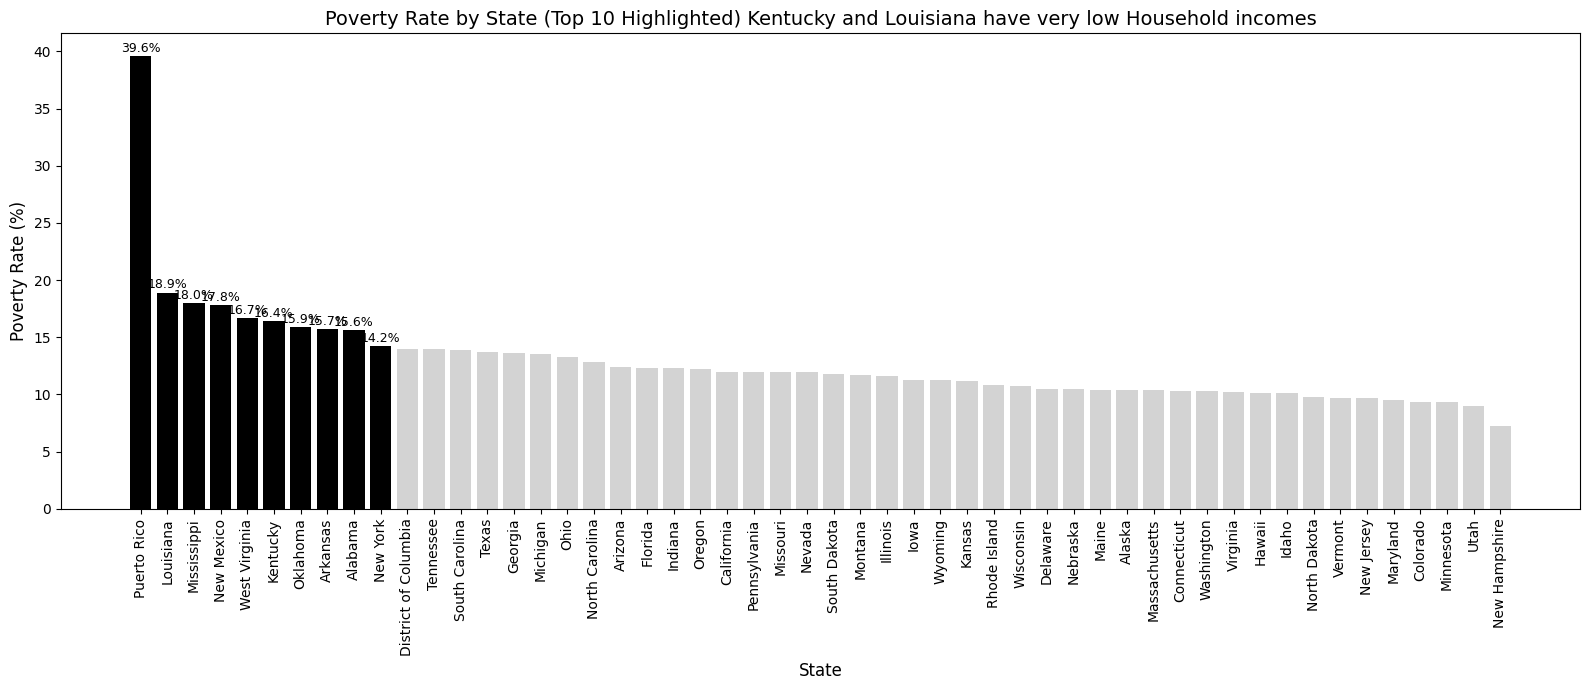

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy data
plot_df = poverty_df.copy()

# Remove national total
plot_df = plot_df[plot_df["Area"] != "United States"]

# Sort all states by poverty rate (highest to lowest)
plot_df = plot_df.sort_values(
    by="Poverty_Percent_2023",
    ascending=False
)

# Identify top 10 states
top10_states = plot_df.head(10)["Area"].tolist()

# Create colors: black for top 10, light gray for others
colors = [
    "black" if state in top10_states else "lightgray"
    for state in plot_df["Area"]
]

# Create bar plot
plt.figure(figsize=(16, 7))

bars = plt.bar(
    plot_df["Area"],
    plot_df["Poverty_Percent_2023"],
    color=colors
)

# Add labels only for top 10 bars
for bar, state in zip(bars, plot_df["Area"]):
    if state in top10_states:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Titles and labels
plt.title("Poverty Rate by State (Top 10 Highlighted) Kentucky and Louisiana have very low Household incomes", fontsize=14)
plt.xlabel("State", fontsize=12)
plt.ylabel("Poverty Rate (%)", fontsize=12)

# Rotate labels
plt.xticks(rotation=90)

# Clean spacing
plt.tight_layout()
plt.show()

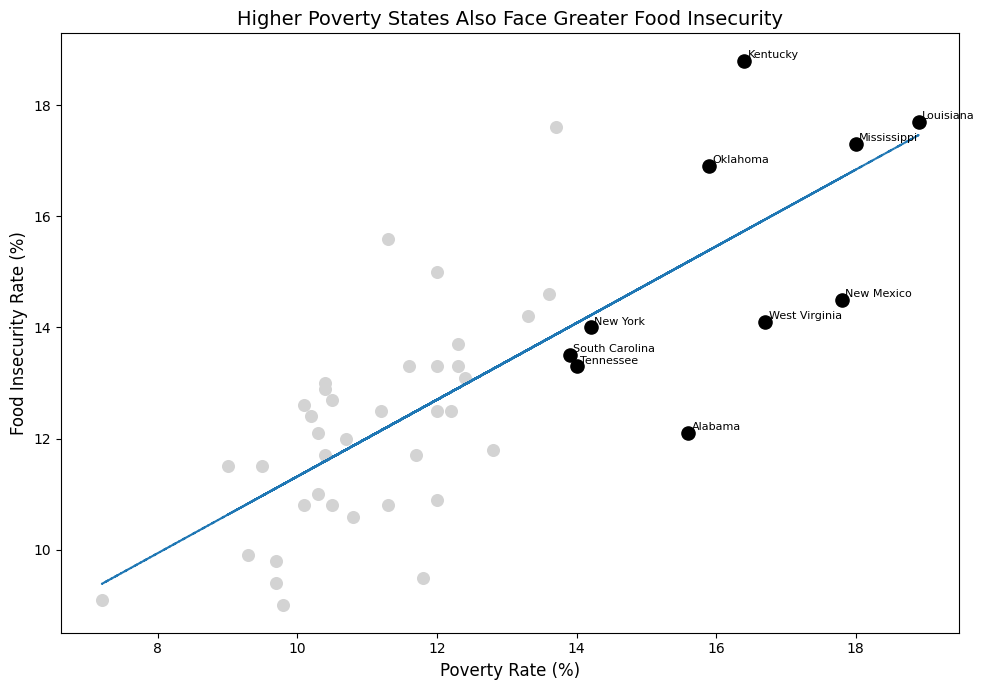

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare poverty data
# -----------------------------
poverty = poverty_df.copy()
poverty = poverty[poverty["Area"] != "United States"]

# Convert state names to abbreviations
reverse_state_map = {v: k for k, v in state_map.items()}
poverty["State"] = poverty["Area"].map(reverse_state_map)

# Keep only needed columns
poverty = poverty[["State", "Area", "Poverty_Percent_2023"]]

# -----------------------------
# Prepare food insecurity data
# -----------------------------
food = Usda_df.copy()

food["Food insecurity prevalence (percent)"] = pd.to_numeric(
    food["Food insecurity prevalence (percent)"],
    errors="coerce"
)

food = food[["State", "Food insecurity prevalence (percent)"]]

# -----------------------------
# Merge datasets
# -----------------------------
merged_df = pd.merge(
    poverty,
    food,
    on="State",
    how="inner"
)

# -----------------------------
# Identify top 10 poverty states
# -----------------------------
top10_states = (
    merged_df.sort_values(
        by="Poverty_Percent_2023",
        ascending=False
    )
    .head(10)["State"]
    .tolist()
)

# -----------------------------
# Create scatter plot
# -----------------------------
plt.figure(figsize=(10, 7))

# Plot all states in light gray
plt.scatter(
    merged_df["Poverty_Percent_2023"],
    merged_df["Food insecurity prevalence (percent)"],
    color="lightgray",
    s=70
)

# Highlight top 10 poverty states in black
highlight = merged_df[merged_df["State"].isin(top10_states)]

plt.scatter(
    highlight["Poverty_Percent_2023"],
    highlight["Food insecurity prevalence (percent)"],
    color="black",
    s=90
)

# -----------------------------
# Add state labels for top 10
# -----------------------------
for _, row in highlight.iterrows():
    plt.text(
        row["Poverty_Percent_2023"] + 0.05,
        row["Food insecurity prevalence (percent)"] + 0.05,
        row["Area"],
        fontsize=8
    )

# -----------------------------
# Add trend line
# -----------------------------
x = merged_df["Poverty_Percent_2023"]
y = merged_df["Food insecurity prevalence (percent)"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linestyle="--"
)

# -----------------------------
# Labels and title
# -----------------------------
plt.title(
    "Higher Poverty States Also Face Greater Food Insecurity",
    fontsize=14
)

plt.xlabel("Poverty Rate (%)", fontsize=12)
plt.ylabel("Food Insecurity Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

insecure_url = "https://raw.githubusercontent.com/prnakyazze94/Data-612-Summer-2025/refs/heads/main/HouseHold_food_insecurity"

food_df = pd.read_csv(insecure_url, sep="\t")

print(food_df.head())
print(food_df.columns)

  Type of household characteristic   Household characteristic  \
0                   All households             All households   
1            Household composition   With children < 18 years   
2            Household composition  With children < 6 years     
3            Household composition    Married-couple families   
4            Household composition     Female head, no spouse   

   Percent of U.S. households in 2023  Percent of U.S. households in 2024  \
0                                13.5                                13.7   
1                                17.9                                18.4   
2                                17.9                                17.8   
3                                11.1                                10.9   
4                                34.7                                36.8   

   Percentage point change from 2023 to 2024  \
0                                        0.2   
1                                        0.5   
2 

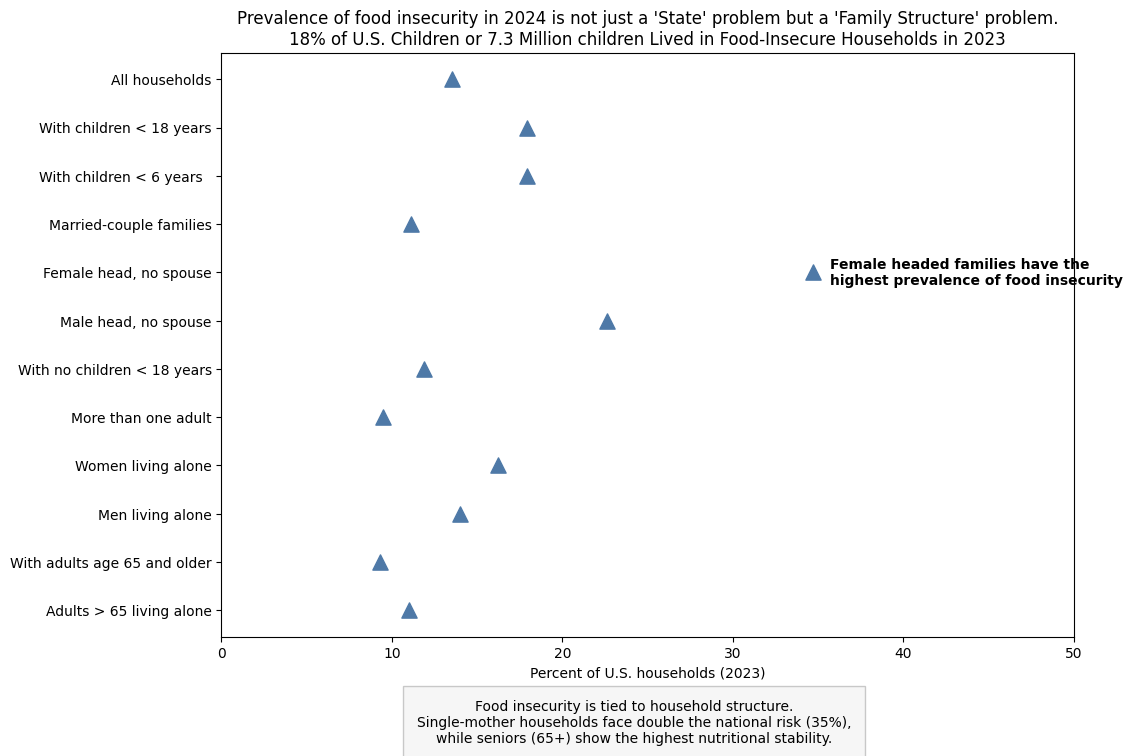

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtering for the Household composition category
plot_df = food_df[food_df['Type of household characteristic'].isin(['All households', 'Household composition'])].copy()

fig, ax = plt.subplots(figsize=(11, 8)) # Increased height slightly for the bottom box
y_pos = range(len(plot_df))

# 2. Plotting 2023 data
ax.scatter(plot_df['Percent of U.S. households in 2023'], y_pos, color='#4e79a7', marker='^', s=120)

# 3. Add text annotation for "Female head, no spouse"
val_2023 = plot_df.iloc[4]['Percent of U.S. households in 2023']
ax.text(val_2023 + 1, 4,
        'Female headed families have the\nhighest prevalence of food insecurity',
        va='center', fontsize=10, color='black', fontweight='bold')

# 4. Chart formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Household characteristic'])
ax.invert_yaxis()
ax.set_xlabel('Percent of U.S. households (2023)')
ax.set_xlim(0, 50)

# --- Vertical line removed from here ---

# 5. Updated Title
plt.title("Prevalence of food insecurity in 2024 is not just a 'State' problem but a 'Family Structure' problem.\n"
          "18% of U.S. Children or 7.3 Million children Lived in Food-Insecure Households in 2023")

# 6. Add a summary box at the bottom of the chart
# Adjusted y-position to 0.02 so it sits inside the figure area
summary_text = (
    "Food insecurity is tied to household structure.\n"
    "Single-mother households face double the national risk (35%),\n"
    "while seniors (65+) show the highest nutritional stability."
)

plt.figtext(0.5, 0.02, summary_text, wrap=True, horizontalalignment='center',
            fontsize=10, bbox={'facecolor':'lightgray', 'alpha':0.2, 'pad':10})

# 7. Final display adjustments
plt.subplots_adjust(bottom=0.15) # Create space at the bottom for the text box
plt.show() # MUST BE LAST

In [80]:
import pandas as pd

# URL of the raw CSV file
url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Education_Score_food_security"

# Read the CSV into a DataFrame named educ_df
educ_df = pd.read_csv(url)

# Display the first few rows to verify the data
educ_df.head()

,Rank,State,Grade,Education Score,Overall Score,Key Metrics,Region
0,1,Massachusetts,A+,100.0,72.8,Education rank #1 of 50,Northeast
1,2,Connecticut,A+,98.0,73.5,Education rank #2 of 50,Northeast
2,3,New Jersey,A+,95.9,65.9,Education rank #3 of 50,Northeast
3,4,Utah,A+,93.9,79.3,Education rank #4 of 50,West
4,5,New Hampshire,A+,91.8,87.8,Education rank #5 of 50,Northeast


In [81]:
print(Usda_df.head())
print(Usda_df.columns)

  State Number of households (average 2022–2024)1 Number Interviewed  \
0    AK                                   283,000              1,143   
1    AL                                 2,075,000              1,886   
3    AZ                                 2,948,000              1,370   
4    CA                                13,990,000              8,112   
6    CT                                 1,444,000                931   

   Food insecurity prevalence (percent)  \
0                                  13.0   
1                                  12.1   
3                                  13.1   
4                                  12.5   
6                                  12.1   

  Statistical significance indicator for food insecurity prevalence  \
0                                                 No                  
1                                                 No                  
3                                                 No                  
4                       

In [82]:
# 1. Merge education + Usda_df
# Use suffixes=('', '_drop') to keep the 'State' name from educ_df clean
merged_df = educ_df.merge(
    Usda_df,
    left_on="State",      # Full name in educ_df
    right_on="State_Full", # Full name in Usda_df
    how="inner",
    suffixes=('', '_drop')
)

# 2. Merge with poverty_df
# Now 'State' exists clearly in merged_df to match with 'Area'
merged_df = merged_df.merge(
    poverty_df,
    left_on="State",
    right_on="Area",
    how="inner"
)

# 3. Rename columns for the scatter plot
merged_df = merged_df.rename(columns={
    "Food insecurity prevalence (percent)": "Food_Insecurity_Percent",
    "Poverty_Percent_2023": "Poverty_Rate"
})

print(f"Success! Number of states merged: {len(merged_df)}")
merged_df.head()

Success! Number of states merged: 47


,Rank,State,Grade,Education Score,Overall Score,Key Metrics,Region,State_drop,Number of households (average 2022–2024)1,Number Interviewed,...,Statistical significance indicator for very low food security prevalence,Margin of error2 for very low food security prevalence (percentage points),Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,State_Full,Area,Poverty_Rate
0,1,Massachusetts,A+,100.0,72.8,Education rank #1 of 50,Northeast,MA,"2,840,000","2,054",...,Yes,0.88,NaN,NaN,NaN,NaN,NaN,Massachusetts,Massachusetts,10.4
1,2,Connecticut,A+,98.0,73.5,Education rank #2 of 50,Northeast,CT,"1,444,000",931,...,No,1.60,NaN,NaN,NaN,NaN,NaN,Connecticut,Connecticut,10.3
2,3,New Jersey,A+,95.9,65.9,Education rank #3 of 50,Northeast,NJ,"3,572,000","1,790",...,Yes,0.87,NaN,NaN,NaN,NaN,NaN,New Jersey,New Jersey,9.7
3,4,Utah,A+,93.9,79.3,Education rank #4 of 50,West,UT,"1,166,000","1,381",...,No,1.02,NaN,NaN,NaN,NaN,NaN,Utah,Utah,9.0
4,5,New Hampshire,A+,91.8,87.8,Education rank #5 of 50,Northeast,NH,"578,000","1,343",...,No,1.35,NaN,NaN,NaN,NaN,NaN,New Hampshire,New Hampshire,7.2


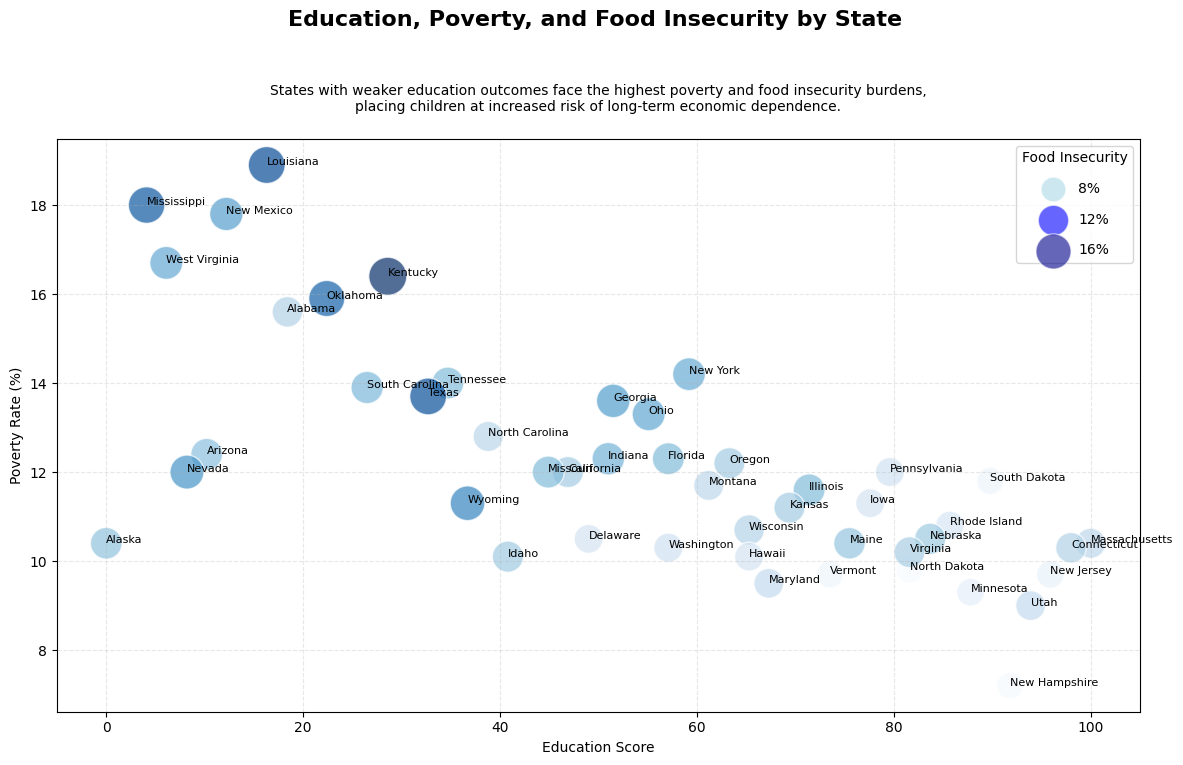

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# 1. Define bubble sizes and colors based on food insecurity
sizes = merged_df["Food_Insecurity_Percent"] * 40
colors = merged_df["Food_Insecurity_Percent"]

# 2. Main scatter plot with gradient colors (Blues)
scatter = plt.scatter(
    merged_df["Education Score"],
    merged_df["Poverty_Rate"],
    s=sizes,
    c=colors,           # Map color to food insecurity
    cmap='Blues',       # Apply the shades of blue
    alpha=0.7,          # Transparency for overlapping bubbles
    edgecolors="w"      # White edges for better definition
)

# 3. Add state labels
for i, row in merged_df.iterrows():
    plt.text(
        row["Education Score"],
        row["Poverty_Rate"],
        row["State"],
        fontsize=8
    )

plt.xlabel("Education Score")
plt.ylabel("Poverty Rate (%)")

# 4. Titles and Subtitles
plt.suptitle(
    "Education, Poverty, and Food Insecurity by State",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

subtitle_text = (
    "States with weaker education outcomes face the highest poverty and food insecurity burdens,\n"
    "placing children at increased risk of long-term economic dependence."
)
plt.title(subtitle_text, fontsize=10, pad=20)

plt.grid(True, linestyle="--", alpha=0.3)

# 5. Create legend bubbles with gradient blues (Updated)
legend_sizes = [8, 12, 16]
legend_colors = ["lightblue", "blue", "darkblue"]

for size, color in zip(legend_sizes, legend_colors):
    plt.scatter(
        [],
        [],
        s=size * 40,
        alpha=0.6,
        color=color,
        edgecolors="w",
        label=f"{size}%"
    )

plt.legend(
    title="Food Insecurity",
    scatterpoints=1,
    frameon=True,
    labelspacing=1.2,
    loc="upper right"
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [93]:
# @title
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- 1. DATA PREPARATION & CLEANING ---
df_map = percapita.copy()

if 'States' not in df_map.columns:
    df_map = df_map.reset_index()

df_map['Clean_State'] = df_map['States'].astype(str)\
    .str.replace(r'\[.*\]', '', regex=True).str.strip()

state_to_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'Washington D.C.': 'DC'
}

df_map['State_Abbrev'] = df_map['Clean_State'].map(state_to_abbrev)
df_map = df_map.dropna(subset=['State_Abbrev'])

# --- 2. MERGE FOOD INSECURITY DATA ---
df_map = df_map.merge(
    merged_df[['State', 'Food_Insecurity_Percent']],
    left_on='Clean_State',
    right_on='State',
    how='left'
)

df_map['Food_Insecurity_Percent'] = pd.to_numeric(
    df_map['Food_Insecurity_Percent'], errors='coerce'
).fillna(0)

# Labels (Income in K)
df_map['Label'] = df_map.apply(
    lambda x: f"{x['State_Abbrev']}<br>{int(x['2023']/1000)}K"
    if not pd.isna(x['2023']) else x['State_Abbrev'], axis=1
)

# Bottom 10 income states
bottom_10_states = df_map.sort_values(by='2023').head(10)['State_Abbrev'].tolist()

# --- 3. BASE MAP ---
fig = px.choropleth(
    df_map,
    locations="State_Abbrev",
    locationmode="USA-states",
    color="2023",
    scope="usa",
    color_continuous_scale="Blues"
)

# --- 4. HIGHLIGHT LOW-INCOME STATES ---
fig.add_choropleth(
    locations=bottom_10_states,
    locationmode="USA-states",
    z=[1]*len(bottom_10_states),
    colorscale=[[0, 'lightgray'], [1, 'lightgray']],
    showscale=False,
    marker_line_color='black',
    name="Lowest Income States"
)

# --- 5. ADD STATE LABELS ---
centroids = {
    "AL":[32.8,-86.8],"AK":[64.2,-149.5],"AZ":[34.2,-111.6],"AR":[34.9,-92.3],
    "CA":[36.7,-119.4],"CO":[39.0,-105.5],"CT":[41.6,-72.7],"DE":[39.0,-75.5],
    "FL":[27.8,-81.7],"GA":[32.7,-83.3],"HI":[20.8,-156.3],"ID":[44.2,-114.6],
    "IL":[40.0,-89.2],"IN":[40.0,-86.1],"IA":[42.1,-93.5],"KS":[38.5,-98.0],
    "KY":[37.8,-85.8],"LA":[31.2,-92.3],"ME":[45.3,-69.0],"MD":[39.0,-76.7],
    "MA":[42.3,-71.8],"MI":[44.3,-85.6],"MN":[46.3,-94.2],"MS":[32.7,-89.7],
    "MO":[38.5,-92.5],"MT":[46.9,-110.3],"NE":[41.5,-99.7],"NV":[39.3,-116.6],
    "NH":[43.7,-71.6],"NJ":[40.1,-74.7],"NM":[34.4,-106.1],"NY":[42.9,-75.0],
    "NC":[35.5,-79.0],"ND":[47.5,-100.5],"OH":[40.4,-82.8],"OK":[35.6,-97.5],
    "OR":[44.0,-120.6],"PA":[41.0,-77.7],"RI":[41.7,-71.5],"SC":[33.8,-80.9],
    "SD":[44.5,-100.0],"TN":[35.8,-86.4],"TX":[31.0,-99.0],"UT":[39.3,-111.7],
    "VT":[44.0,-72.7],"VA":[37.5,-78.7],"WA":[47.4,-120.5],"WV":[38.6,-80.6],
    "WI":[44.5,-89.5],"WY":[43.0,-107.5],"DC":[38.9,-77.0]
}

fig.add_trace(go.Scattergeo(
    lat=[centroids[s][0] for s in df_map['State_Abbrev'] if s in centroids],
    lon=[centroids[s][1] for s in df_map['State_Abbrev'] if s in centroids],
    text=[df_map[df_map['State_Abbrev'] == s]['Label'].values[0]
          for s in df_map['State_Abbrev'] if s in centroids],
    mode="text",
    textfont=dict(color="black", size=9),
    showlegend=False
))

# --- 6. FOOD INSECURITY BUBBLES ---
fig.add_trace(go.Scattergeo(
    locations=df_map['State_Abbrev'],
    locationmode="USA-states",
    marker=dict(
        size=df_map['Food_Insecurity_Percent'] * 3.5,
        color=df_map['Food_Insecurity_Percent'],
        colorscale='Blues',
        showscale=False,
        line_color='white',
        line_width=1,
        opacity=0.8
    ),
    text=df_map['Clean_State'] + "<br>Food Insecurity: "
         + df_map['Food_Insecurity_Percent'].astype(str) + "%",
    name="Food Insecurity"
))

# --- 7. LEGEND ITEMS ---
for val, col in zip([8, 12, 16], ["#deebf7", "#4292c6", "#084594"]):
    fig.add_trace(go.Scattergeo(
        lat=[None], lon=[None],
        marker=dict(size=val * 3.5, color=col, line_color='white'),
        name=f"{val}% Insecurity"
    ))

fig.add_trace(go.Scattergeo(
    lat=[None], lon=[None],
    marker=dict(size=12, color='lightgray', symbol='square',
                line_color='black'),
    name="Lowest Income States"
))

# --- 8. FINAL LAYOUT (EXPANDED MAP) ---
fig.update_layout(
    title=dict(
        text="<b>Low Income States Face the Highest Risk of Long Term Childhood Food Insecurity</b><br>"
        "States like Kentucky, Oklahoma, Louisiana, Mississippi and Wyoming",
        x=0.5,
        y=0.96
    ),
    coloraxis_colorbar=dict(
        title="<b>Annual Income</b>",
        thickness=8,
        len=0.40,
        y=0.5,
        x=1.05,   # push further right
        tickprefix="$",
        tickformat=","
    ),
    legend=dict(
        title="<b>Nutrition & Income Scale</b>",
        y=0.05,
        x=0.01,
        bgcolor="rgba(255,255,255,0.7)"
    ),
    margin=dict(l=0, r=60, t=100, b=80),
    font=dict(size=12)
)
# Add the lobbying footnote at the base of the map
fig.add_annotation(
    text=("<b> Children growing up in low income states are at greater risk of food insecurity,</b><br> "
          "which increases the likelihood of poor school performance, chronic health conditions, </b><br> "
          "lower lifetime earnings, and long-term reliance on public assistance."),
    xref="paper", yref="paper",
    x=0.5, y=-0.15,  # Positions it below the X-axis
    showarrow=False,
    font=dict(size=12, color="black"),
    align="center",
    width=800,       # Limits width to wrap text nicely
    bordercolor="gray",
    borderwidth=1,
    borderpad=10,
    bgcolor="rgba(240, 240, 240, 0.8)"
)

# Adjust the margin to make room for the new text
fig.update_layout(margin={"r":0,"t":100,"l":0,"b":100})




fig.show()